# Addition Transformer in JAX

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shoaibphysics/addition-transformers-jax/blob/main/notebooks/01_addition_transformer.ipynb)

This notebook trains a decoder-only Transformer with approximately 10 million parameters to perform character-level addition of two integers from 0 to 999. The one million
ordered operand pairs are divided into 900,000 training, 50,000 validation, and
50,000 test examples.

The data pipeline, model, optimizer, checkpointing, evaluation, export, and
cached generation are implemented as reusable JAX and Flax modules. Here we
connect those pieces into one complete experiment; no earlier notebook is
required.

> **AI assistance statement.** I designed and hand-coded the Transformer architecture and wrote the core data and training modules. AI tools were used selectively for prose editing, code review, small refinements to parts of the training loop, assistance with plotting code, and creation of the two explanatory diagrams. I reviewed and tested every incorporated suggestion; the final implementation, experimental choices, results, and interpretation remain my responsibility.

## Setup

The next cells install the pinned dependencies and locate the project source.
A public Colab session clones the repository into the temporary runtime. Set
`USE_GOOGLE_DRIVE = True` when persistent Colab checkpoints are required.
When run locally, the notebook uses the downloaded repository directly.

In [1]:
%pip -q install "flax==0.12.9" "optax==0.2.8" "orbax-checkpoint==0.12.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 kB 25.5 MB/s eta 0:00:00


In [ ]:
# @title
import importlib.metadata
import subprocess
import sys
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax.training import train_state
from IPython.display import Image, display


PROJECT_NAME = "addition-transformers-jax"
EXPERIMENT_NAME = "01_addition_transformer"
RUN_NAME = "dense-v1"

# PROJECT_ROOT = (
#     Path("/content/drive/MyDrive")
#     / "Colab Notebooks"
#     / PROJECT_NAME)

REPOSITORY_URL = (
    "https://github.com/shoaibphysics/"
    "addition-transformers-jax.git"
)

# Leave False for a public one-click Colab run.
# Set True when persistent Colab checkpoints are required.
USE_GOOGLE_DRIVE = False

try:
  from google.colab import drive
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

if IN_COLAB:
  if USE_GOOGLE_DRIVE:
    drive.mount("/content/drive")

    PROJECT_ROOT = (
        Path("/content/drive/MyDrive")
        / "Colab Notebooks"
        / PROJECT_NAME
    )
  else:
    PROJECT_ROOT = Path("/content") / PROJECT_NAME

  if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT.parent.mkdir(parents=True, exist_ok=True)

    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(PROJECT_ROOT),
        ],
        check=True,
    )

else:
  PROJECT_ROOT = next(
      (
          directory
          for directory in (Path.cwd(), *Path.cwd().parents)
          if (
              (directory / "pyproject.toml").is_file()
              and (
                  directory
                  / "src"
                  / "scaling_transformers_in_jax"
              ).is_dir()
          )
      ),
      None,
  )

  if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Run this notebook from inside the downloaded repository."
    )

SRC_DIR = PROJECT_ROOT / "src"
ASSETS_DIR = PROJECT_ROOT / "notebooks" / "assets"

RUN_DIR = PROJECT_ROOT / "runs" / EXPERIMENT_NAME / RUN_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
EXPORT_DIR = RUN_DIR / "exports"
RESULTS_DIR = RUN_DIR / "results"

for path in (
    ASSETS_DIR,
    CHECKPOINT_DIR,
    EXPORT_DIR,
    RESULTS_DIR):
  path.mkdir(parents=True, exist_ok=True)

src_path = str(SRC_DIR)

if src_path not in sys.path:
  sys.path.insert(0, src_path)

print("JAX:", jax.__version__)
print("Flax:", importlib.metadata.version("flax"))
print("Optax:", importlib.metadata.version("optax"))
print("Orbax:", importlib.metadata.version("orbax-checkpoint"))
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())

Mounted at /content/drive
JAX: 0.11.1
Flax: 0.12.9
Optax: 0.2.8
Orbax: 0.12.4
Backend: gpu
Devices: [CudaDevice(id=0)]


In [3]:
# @title
from scaling_transformers_in_jax.addition_data import (
    SEQ_LEN,
    SPACE,
    SPLIT_SEED,
    TEST_SIZE,
    TRAIN_SIZE,
    VAL_SIZE,
    VOCAB,
    VOCAB_SIZE,
    create_addition_dataset,
    itos,
    stoi)

from scaling_transformers_in_jax.checkpointing import (
    create_checkpoint_manager,
    make_run_metadata,
    restore_latest_checkpoint)

from scaling_transformers_in_jax.evaluation import (
    evaluate_dataset_metrics)

from scaling_transformers_in_jax.exporting import (
    export_parameters,
    load_parameters)

from scaling_transformers_in_jax.generation import (
    generate_greedy_with_cache,
    generate_sampled_with_cache,
    make_cached_apply)

from scaling_transformers_in_jax.training import (
    TrainConfig,
    create_optimizer,
    run_training)

from scaling_transformers_in_jax.transformer import (
    DecoderOnlyTransformer,
    ModelConfig)

## Dataset

The vocabulary contains the digits 0–9, a space, `+`, and `=`. Each ordered
operand pair becomes a string such as `123+456=579 ` and is padded to 13
characters. Shifting this string by one position produces input and target
arrays of length 12. The loss mask includes the terminating space but excludes
any padding that follows it.

A fixed random seed partitions the one million possible ordered pairs into
900,000 training, 50,000 validation, and 50,000 test examples.

In [4]:
# @title
# Dataset shuffling uses the fixed `SPLIT_SEED` defined in `addition_data.py`.
dataset = create_addition_dataset()

train_pairs, train_x, train_y, train_mask = dataset["train"]
val_pairs, val_x, val_y, val_mask = dataset["val"]
test_pairs, test_x, test_y, test_mask = dataset["test"]

print("Training:", train_x.shape)
print("Validation:", val_x.shape)
print("Test:", test_x.shape)
print("Training device:", train_x.devices())

Training: (900000, 12)
Validation: (50000, 12)
Test: (50000, 12)
Training device: {CudaDevice(id=0)}


## Model

The model configuration defines the architecture, while the training configuration defines the optimization procedure. We initialize the model once to create its parameter tree and then place those parameters and the optimizer inside a Flax TrainState.

This initialized state also acts as the structural template Orbax needs when restoring a checkpoint.

We omit dropout in this baseline to keep the model simple; the learning curves
below show no persistent gap between training and validation loss.

In [5]:
# @title
MODEL_SEED = 0
TRAIN_SEED = 2027

model_cfg = ModelConfig(vocab_size=VOCAB_SIZE, context_length=SEQ_LEN)

train_cfg = TrainConfig()  # Default configuration for this baseline run.

assert model_cfg.d_model % model_cfg.num_heads == 0
assert model_cfg.head_dim % 2 == 0

model = DecoderOnlyTransformer(cfg=model_cfg)

example_tokens = train_x[:2]
positions = jnp.arange(model_cfg.context_length, dtype=jnp.int32)

model_variables = model.init(jax.random.key(MODEL_SEED),
                             example_tokens,
                             positions)

example_logits = model.apply(model_variables,
                             example_tokens,
                             positions)

_, optimizer = create_optimizer(train_cfg)

state_template = train_state.TrainState.create(
    apply_fn = model.apply,
    params = model_variables["params"],
    tx = optimizer)

parameter_count = sum(parameter.size for parameter in jax.tree_util.tree_leaves(state_template.params))

print("Model configuration:", model_cfg)
print("Training configuration:", train_cfg)
print("Logits shape:", example_logits.shape)
print(f"Number of parameters: {parameter_count:,}")

Model configuration: ModelConfig(vocab_size=13, context_length=12, d_model=384, num_layers=6, num_heads=6, rope_theta=10000.0, d_ff=1024)
Training configuration: TrainConfig(batch_size=1024, log_every=100, num_eval_batches=4, checkpoint_every=500, warmup_steps=500, learning_rate_decay_step=10000, num_steps=12000, peak_learning_rate=0.0003, end_learning_rate=3e-05, max_grad_norm=1.0, weight_decay=0.1, adam_epsilon=1e-08, adam_beta1=0.9, adam_beta2=0.95)
Logits shape: (2, 12, 13)
Number of parameters: 10,631,808


### Architecture

The model contains six pre-normalized decoder blocks with causal attention,
RoPE, and SwiGLU feed-forward layers. A final RMSNorm and an untied
language-model head produce logits over the 13-character vocabulary.

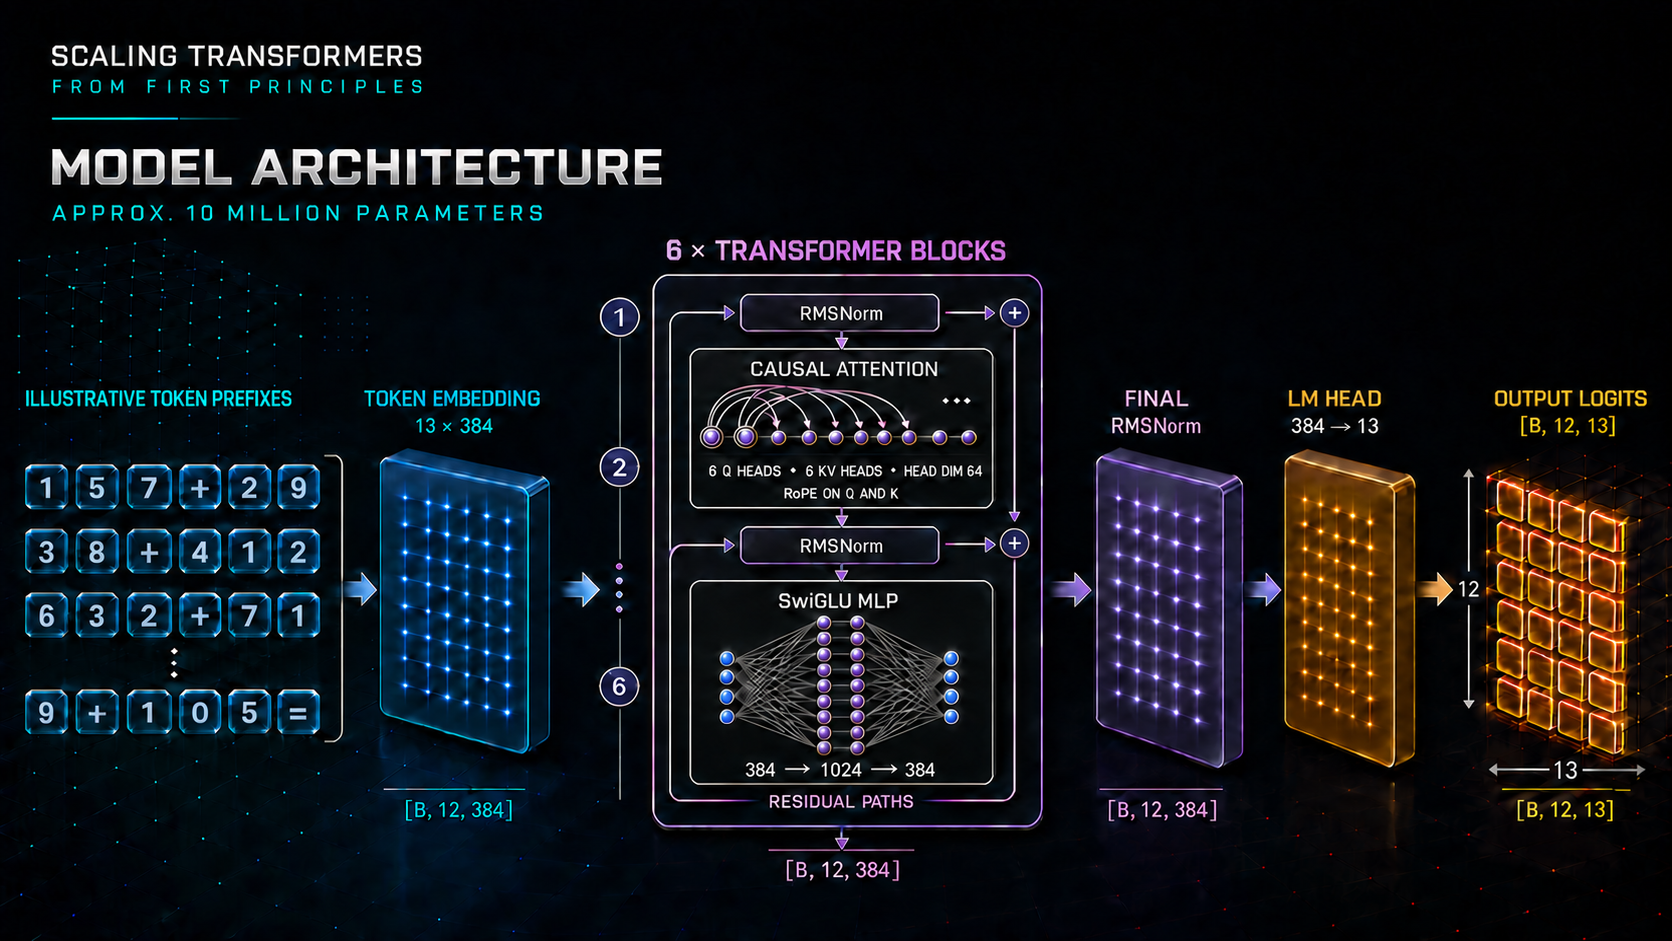

In [6]:
# @title
display(
    Image(
        filename=str(ASSETS_DIR / "01_model_architecture.png"),
        width=1200))

### Parameter count

Because the model uses no bias parameters, its parameter count can be derived
directly from the architecture.

Let

- $V$ be the vocabulary size,
- $d$ be `d_model`,
- $d_{\mathrm{ff}}$ be the SwiGLU hidden dimension, and
- $L$ be the number of Transformer layers.

The token embedding and untied language-modeling head each contain $Vd$
parameters.

Within every Transformer layer:

- the query, key, value, and output projections contain $4d^2$ parameters;
- the three SwiGLU projections contain $3d\,d_{\mathrm{ff}}$ parameters; and
- the two RMSNorm scale vectors contain $2d$ parameters.

The final RMSNorm contributes another $d$ parameters. Therefore,

$$
N
=
2Vd
+
L\left(
4d^2
+
3d\,d_{\mathrm{ff}}
+
2d
\right)
+
d.
$$

RoPE, the causal mask, and the KV cache contain no learned parameters.

For the present configuration,

$$
V=13,\qquad
d=384,\qquad
d_{\mathrm{ff}}=1024,\qquad
L=6,
$$

which gives

$$
N=10{,}631{,}808.
$$

In [7]:
# @title
vocab_parameters = 2 * model_cfg.vocab_size * model_cfg.d_model
attention_parameters_per_layer = 4 * model_cfg.d_model**2
swiglu_parameters_per_layer = (3 * model_cfg.d_model * model_cfg.d_ff)
norm_parameters_per_layer = 2 * model_cfg.d_model
block_parameters = (attention_parameters_per_layer + swiglu_parameters_per_layer + norm_parameters_per_layer)
analytical_parameter_count = (vocab_parameters + model_cfg.num_layers * block_parameters + model_cfg.d_model)

print(f"Embedding and LM head: {vocab_parameters:,}")
print(f"Attention per layer:    {attention_parameters_per_layer:,}")
print(f"SwiGLU per layer:       {swiglu_parameters_per_layer:,}")
print(f"RMSNorm per layer:      {norm_parameters_per_layer:,}")
print(f"Complete block:         {block_parameters:,}")
print()
print(f"Analytical count:       {analytical_parameter_count:,}")
print(f"Parameter-tree count:   {parameter_count:,}")
print("Counts match:", analytical_parameter_count == parameter_count)
assert analytical_parameter_count == parameter_count

Embedding and LM head: 9,984
Attention per layer:    589,824
SwiGLU per layer:       1,179,648
RMSNorm per layer:      768
Complete block:         1,770,240

Analytical count:       10,631,808
Parameter-tree count:   10,631,808
Counts match: True


## Training

### Checkpoint restoration

A checkpoint contains the model parameters, optimizer state, training step, random keys, training history, and experiment metadata.

If the selected run directory contains no checkpoint, we begin from the newly initialized state. If a checkpoint exists, we restore the complete state and continue from its recorded training step.

In [8]:
# @title
checkpoint_manager = create_checkpoint_manager(
    checkpoint_dir = CHECKPOINT_DIR,
    max_to_keep = 3)

run_metadata = make_run_metadata(
    model_cfg=model_cfg,
    train_cfg=train_cfg,
    vocab=VOCAB,
    split_seed=SPLIT_SEED,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE)

if checkpoint_manager.latest_step() is None:
  state = state_template

  train_key, monitor_key = jax.random.split(jax.random.key(TRAIN_SEED))

  training_history = []

  print("Starting a new run.")
else:
  (state,
   train_key,
   monitor_key,
   training_history) = restore_latest_checkpoint(
       checkpoint_manager=checkpoint_manager,
       state_template=state_template,
       expected_metadata=run_metadata)

/usr/local/lib/python3.13/dist-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:976: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Restored checkpoint at step 12000.


### Optimization

Each optimizer step samples 1,024 examples from the training split with
replacement and minimizes masked next-character cross-entropy, equivalently negative
log-likelihood (NLL). We clip the
global gradient norm at 1.0 and update the parameters with AdamW.

The learning rate warms from zero to $3\times10^{-4}$ over 500 steps, follows
cosine decay to $3\times10^{-5}$ at step 10,000, and remains there through the
12,000-step endpoint.

During training, validation loss is monitored on a fixed subset of 1,024
examples. This keeps monitoring inexpensive while ensuring that every
measurement uses the same examples.

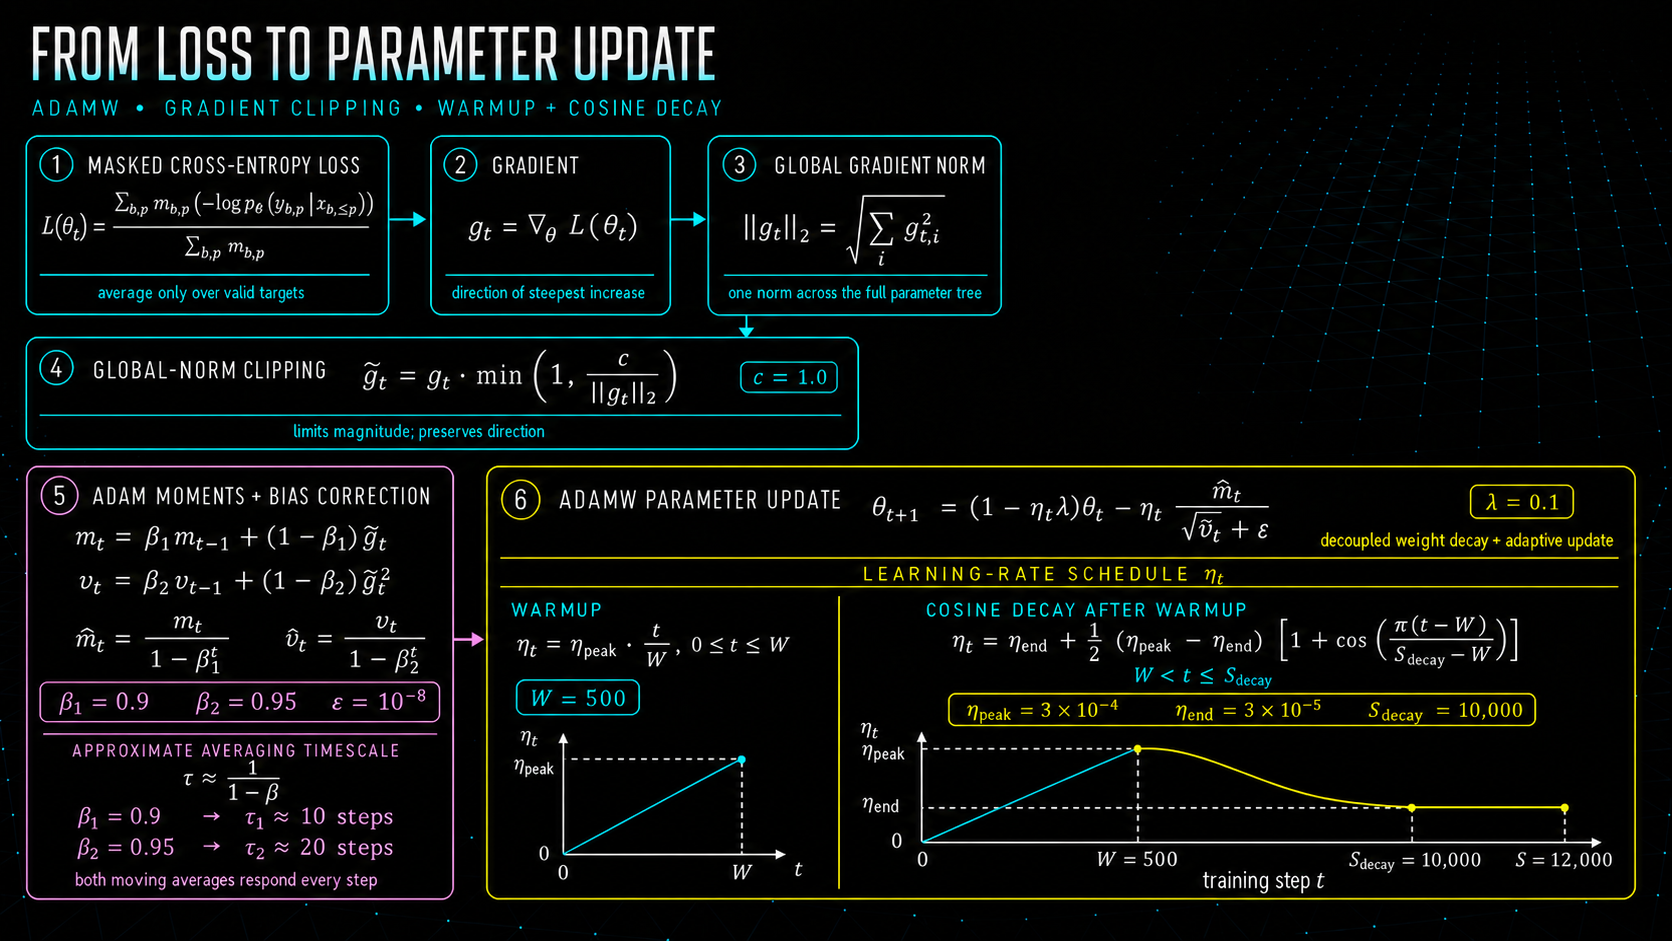

In [9]:
# @title
display(
    Image(
        filename=str(ASSETS_DIR / "01_training_update.png"),
        width=1200))

In [10]:
# @title
VALIDATION_MONITOR_SIZE = 1_024

try:
  (state,
   train_key,
   monitor_key,
   training_history) = run_training(state=state,
                                    train_key=train_key,
                                    monitor_key=monitor_key,
                                    training_data=(train_x,
                                                   train_y,
                                                   train_mask),
                                    validation_data=(val_x[:VALIDATION_MONITOR_SIZE],
                                                     val_y[:VALIDATION_MONITOR_SIZE],
                                                     val_mask[:VALIDATION_MONITOR_SIZE],),
                                    train_cfg=train_cfg,
                                    training_history=training_history,
                                    checkpoint_manager=checkpoint_manager,
                                    run_metadata=run_metadata)
finally:
  checkpoint_manager.close()

Starting training from step 12000.
Checkpoint at step 12000 already exists.

Training finished at step 12000.
Elapsed time: 0.00 seconds (0.00 minutes)


### Training curves

We plot both training and validation cross-entropy against the completed training step. The checkpoint contains the recorded history, so the same plot can be reconstructed after restoring a run.

Because this loss covers the complete sequence, it also scores operand
characters that cannot always be inferred from their preceding characters.
Full-sequence NLL therefore has a nonzero floor and need not approach zero
when the model has learned addition. Answer-only metrics provide a more direct
measurement of arithmetic performance.

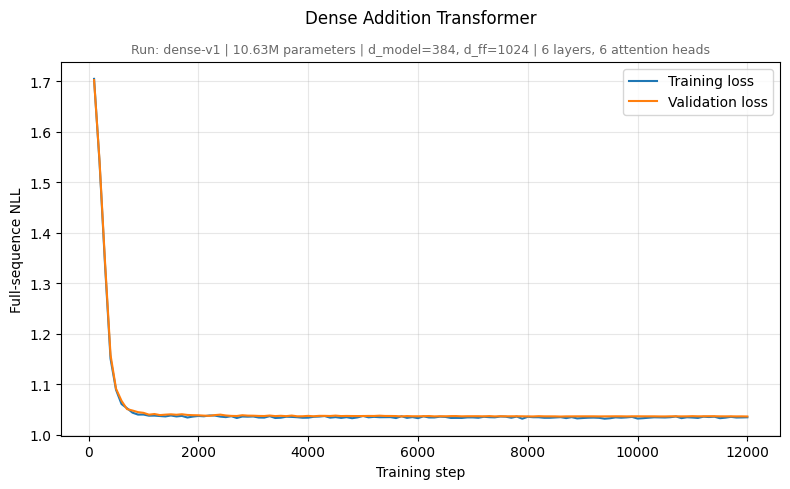

Saved plot to: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/01_addition_transformer/dense-v1/results/loss_curve.png


In [11]:
# @title
if training_history:
  steps = [record["step"] for record in training_history]

  train_losses = [record["train_loss"] for record in training_history]

  validation_losses = [record["validation_loss"] for record in training_history]

  plot_path = RESULTS_DIR / "loss_curve.png"

  model_details = (
    f"Run: {RUN_NAME} | "
    f"{parameter_count / 1e6:.2f}M parameters | "
    f"d_model={model_cfg.d_model}, d_ff={model_cfg.d_ff} | "
    f"{model_cfg.num_layers} layers, "
    f"{model_cfg.num_heads} attention heads")

  plt.figure(figsize=(8, 5))
  plt.plot(steps, train_losses, label="Training loss")
  plt.plot(steps, validation_losses, label="Validation loss")

  plt.xlabel("Training step")
  plt.ylabel("Full-sequence NLL")
  plt.title("Dense Addition Transformer", pad=28)
  plt.gca().text(
      0.5,
      1.015,
      model_details,
      transform=plt.gca().transAxes,
      ha="center",
      va="bottom",
      fontsize=9,
      color="dimgray")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()

  plt.savefig(plot_path,dpi=150,bbox_inches="tight")

  plt.show()

  print("Saved plot to:", plot_path)
else:
  print("No logged training history is available yet.")

### Why the full-sequence loss plateaus near 1.03

The model is trained to predict the complete character sequence, not only the
answer. Even a perfect addition model cannot predict operand characters that
were sampled uniformly at random before those characters appear. The answer,
delimiters, and terminating space become deterministic once the two operands
are known, but the prompt itself retains irreducible uncertainty.

Let $A$ and $B$ be independent and uniformly distributed over
$\{0,\ldots,999\}$, and let $F$ be the first decimal character of $A$. Because
the first character is supplied as an input rather than scored as a target, the
minimum expected summed NLL for one sequence is

$$
H(A,B\mid F)
=
2\log(1000)-H(F).
$$

The first character is `0` for one value of $A$, while each of `1` through `9`
is the first character for 111 values. Therefore,

$$
H(F)
=
-\frac{1}{1000}\log\left(\frac{1}{1000}\right)
-
9\frac{111}{1000}
\log\left(\frac{111}{1000}\right)
\approx 2.202935.
$$

This gives

$$
H(A,B\mid F)
\approx
11.612576
$$

nats per example. Under the same uniform distribution, the mean number of
scored target characters is

$$
\mathbb{E}[n_{\mathrm{scored}}]
=
11.274395.
$$

The theoretical full-sequence loss floor is consequently

$$
E_{\mathrm{full}}
=
\frac{11.612576}{11.274395}
\approx
1.029995
\quad\text{nats per token}.
$$

In [12]:
# @title
from math import log

first_probs = [1 / 1000] + [111 / 1000] * 9
first_char_entropy = -sum(p * log(p) for p in first_probs)

mean_scored_tokens = sum(
    len(f"{a}+{b}={a+b} ") - 1
    for a in range(1000)
    for b in range(1000)
) / 1_000_000

E_full = (
    2 * log(1000) - first_char_entropy
) / mean_scored_tokens

print(f"H(A, B | F): {2 * log(1000) - first_char_entropy:.6f}")
print(f"E[n_scored]: {mean_scored_tokens:.6f}")
print(f"E_full:      {E_full:.10f}")

H(A, B | F): 11.612576
E[n_scored]: 11.274395
E_full:      1.0299954854


### Held-out evaluation

We evaluate the complete 50,000-example test split once after training.
Answer-only NLL scores the answer digits and terminating space.
Teacher-forced exact-answer accuracy requires every answer token to be
predicted correctly when conditioned on the true preceding sequence.

In [13]:
# @title
test_metrics = evaluate_dataset_metrics(
    state=state,
    inputs=test_x,
    targets=test_y,
    loss_mask=test_mask,
    equals_id=VOCAB.index("="),
    batch_size=1_000)

print(f"Full-sequence test NLL:              {test_metrics['full_loss']:.6f}")
print(f"Answer-only test NLL:                {test_metrics['answer_loss']:.6f}")
print(
    "Teacher-forced exact-answer accuracy:",
    f"{test_metrics['exact_answer_accuracy']:.4%}")

Full-sequence test NLL:              1.034743
Answer-only test NLL:                0.000003
Teacher-forced exact-answer accuracy: 100.0000%


The observed test NLL of $1.034743$ is therefore close to the theoretical
floor. At the same time, the answer-only NLL is approximately
$3\times10^{-6}$ and teacher-forced exact-answer accuracy is $100\%$. The
nonzero full-sequence loss reflects uncertainty in the randomly generated
prompt, not a failure to learn addition.

## Save and verify

### Export

Checkpoints preserve the complete training state and allow training to resume. An export is lighter: it stores only the trained model parameters together with metadata describing the model configuration, vocabulary, and training step.

In [14]:
# @title
params_path, metadata_path = export_parameters(
    export_dir=EXPORT_DIR,
    state=state,
    model_cfg=model_cfg,
    vocab=VOCAB)

print("Parameters:", params_path)
print("Metadata:", metadata_path)

Exported parameters to /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/01_addition_transformer/dense-v1/exports/params_step_12000.msgpack
Parameters: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/01_addition_transformer/dense-v1/exports/params_step_12000.msgpack
Metadata: /content/drive/MyDrive/Colab Notebooks/scaling-addition-transformers-jax/runs/01_addition_transformer/dense-v1/exports/params_step_12000.json


### Verify the exported parameters

To verify the export, we reload the serialized parameters using the current parameter tree as a structural template. We then confirm that the reloaded parameters exactly match the trained parameters and produce the same model logits.

In [15]:
# @title
loaded_params = load_parameters(
    params_path=params_path,
    params_template=state.params)

original_logits = model.apply(
    {"params": state.params},
    example_tokens,
    positions)

loaded_logits = model.apply(
    {"params": loaded_params},
    example_tokens,
    positions)

parameters_match = jax.tree_util.tree_all(
    jax.tree_util.tree_map(
        jnp.array_equal,
        state.params,
        loaded_params))

logits_match = jnp.allclose(original_logits, loaded_logits)

print("Parameters match:", parameters_match)
print("Logits match:", bool(jax.device_get(logits_match)))

Parameters match: True
Logits match: True


## Generation

Given a prompt ending in `=`, the model predicts one character at a time until
it emits the terminating space. A KV cache reuses keys and values from the
prefix, so each subsequent step processes only the latest token. Greedy
decoding is the appropriate default for arithmetic.

We first test valid additions within the model's 12-position training context.
We then demonstrate temperature, top-k, and top-p controls on exploratory
prompts using a larger inference-only cache. This changes neither the learned
parameters nor the training context. Generation stops at the terminating space
or `MAX_NEW_TOKENS`; outputs beyond the original context are behavioral probes,
not arithmetic evaluations.

In [16]:
# @title
cached_apply = make_cached_apply(model)

# Use state.params instead if the export was not reloaded.
inference_params = loaded_params

MAX_PROMPT_TOKENS = model_cfg.context_length
MAX_NEW_TOKENS = 20

generation_cfg = replace(model_cfg,context_length=MAX_PROMPT_TOKENS + MAX_NEW_TOKENS)
generation_model = DecoderOnlyTransformer(cfg=generation_cfg)
generation_cached_apply = make_cached_apply(generation_model)

In [17]:
# @title
demo_pairs = [(2, 3), (17, 25), (123, 456)]

for a, b in demo_pairs:
  prompt = f"{a}+{b}="

  generated_text = generate_greedy_with_cache(
      cached_apply=cached_apply,
      params=inference_params,
      prompt=prompt,
      stoi=stoi,
      itos=itos,
      space_id=SPACE,
      context_length=model_cfg.context_length)

  expected_text = f"{a}+{b}={a+b}"

  print("Generated:", generated_text)
  print("Expected: ", expected_text)
  print("Correct:  ", generated_text == expected_text)
  print()

Generated: 2+3=5
Expected:  2+3=5
Correct:   True

Generated: 17+25=42
Expected:  17+25=42
Correct:   True

Generated: 123+456=579
Expected:  123+456=579
Correct:   True



In [18]:
# @title
# The model application is already JIT-compiled by make_cached_apply.
# This Python helper remains un-jitted because it handles strings, dictionaries, loops, and printing.
def compare_decoding_methods(prompt):
  if not 0 < len(prompt) <= MAX_PROMPT_TOKENS:
    raise ValueError(f"The prompt must contain between 1 and {MAX_PROMPT_TOKENS} characters.")

  sampling_key = jax.random.key(2028)

  sampling_methods = [("Temperature",{"temperature": 0.7}),
                      ("Top-k",{"temperature": 0.7,"top_k": 3}),
                      ("Top-p",{"temperature": 0.7, "top_p": 0.9}),
                      ("Top-k + top-p",{"temperature": 0.7,"top_k": 3,"top_p": 0.9})]

  print("-" * 50)
  print(f"Prompt: {prompt}")

  generated_text, finish_reason = generate_greedy_with_cache(
      cached_apply=generation_cached_apply,
      params=inference_params,
      prompt=prompt,
      stoi=stoi,
      itos=itos,
      space_id=SPACE,
      context_length=generation_cfg.context_length,
      max_new_tokens=MAX_NEW_TOKENS,
      return_finish_reason=True)

  print(f"{'Greedy':15}: {generated_text} [{finish_reason}]")

  for method_name, settings in sampling_methods:
    generated_text, sampling_key, finish_reason = (
        generate_sampled_with_cache(
            cached_apply=generation_cached_apply,
            params=inference_params,
            prompt=prompt,
            stoi=stoi,
            itos=itos,
            space_id=SPACE,
            context_length=generation_cfg.context_length,
            sampling_key=sampling_key,
            max_new_tokens=MAX_NEW_TOKENS,
            **settings))

    print(f"{method_name:15}: {generated_text} [{finish_reason}]")

  print("-" * 50)

In [19]:
# @title
compare_decoding_methods("123+23=")
compare_decoding_methods("+++")
compare_decoding_methods("12+1")
compare_decoding_methods("100++20=")

--------------------------------------------------
Prompt: 123+23=
Greedy         : 123+23=146 [stop]
Temperature    : 123+23=146 [stop]
Top-k          : 123+23=146 [stop]
Top-p          : 123+23=146 [stop]
Top-k + top-p  : 123+23=146 [stop]
--------------------------------------------------
--------------------------------------------------
Prompt: +++
Greedy         : +++11=11 [stop]
Temperature    : +++8=16 [stop]
Top-k          : +++591=591 [stop]
Top-p          : +++728=728 [stop]
Top-k + top-p  : +++11=112 [stop]
--------------------------------------------------
--------------------------------------------------
Prompt: 12+1
Greedy         : 12+191=203 [stop]
Temperature    : 12+18=30 [stop]
Top-k          : 12+199=211 [stop]
Top-p          : 12+12=24 [stop]
Top-k + top-p  : 12+189=201 [stop]
--------------------------------------------------
--------------------------------------------------
Prompt: 100++20=
Greedy         : 100++20=120 [stop]
Temperature    : 100++20=120 [stop

The valid addition prompt is solved consistently. The remaining prompts are
incomplete or outside the training grammar, so their continuations illustrate
decoder behavior rather than arithmetic accuracy. Greedy decoding remains the
default for the task.